# Heteroscedastic DPGMM: Exploiting Gaussian Embeddings for Clustering

Evaluates the **heteroscedastic DPGMM** clusterer, which folds per-sample
embedding variance into the EM likelihood ($\Sigma_{ik} = C_k + S_i$) and
discovers the number of clusters automatically via a Dirichlet prior with
post-EM component merging.

NL and UG share the same mean network (UG's mean is copied from NL).
The only difference is that UG also provides per-sample diagonal variance.
This lets us cleanly isolate the effect of feeding variance into clustering.

Compares:
- **sklearn DPGMM** on shared point estimates (baseline, ignores variance)
- **Het. DPGMM** on UG Gaussian embeddings (heteroscedastic EM path, variance folded into likelihood)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.mixture import BayesianGaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from embedders.base import EmbeddingResult
from clustering.dpgmm import DPGMMClusterer
from evaluation.eval_utils import (
    align_labels_via_hungarian_algorithm,
    count_high_quality_clusters,
)

# ── Config ──
SEED         = 26042024
MODEL_DIR    = '../../models/notebook/unlabeled_exp'
EMB_DIR      = os.path.join(MODEL_DIR, 'embeddings')
MIN_BIN_SIZE = 5

# Sklearn DPGMM settings (matching clustering_evaluation notebooks)
SKLEARN_PCA_DIM       = 16
SKLEARN_MAX_COMP      = 500
SKLEARN_PRIOR         = 1000

# Heteroscedastic DPGMM settings
# Best Phase 1: alpha=1000.0, merge=1.5, F1>0.9=66, K=178
HET_MAX_COMP    = 500
HET_N_INIT      = 3
HET_MERGE_THRESH = 1.5

print('Setup complete.')

Setup complete.


In [2]:
# ── Load embeddings ──
def load_embedding(name, split):
    path = os.path.join(EMB_DIR, f'{name}_{split}.npz')
    data = np.load(path)
    return EmbeddingResult(
        mean=data['mean'],
        variance=data['variance'] if 'variance' in data else None,
        kappa=data['kappa'] if 'kappa' in data else None,
    )

nl_val  = load_embedding('nl', 'val')
nl_test = load_embedding('nl', 'test')
ug_val  = load_embedding('ug', 'val')
ug_test = load_embedding('ug', 'test')

val_labels  = np.load(os.path.join(EMB_DIR, 'val_labels.npy'))
test_labels = np.load(os.path.join(EMB_DIR, 'test_labels.npy'))
n_species   = len(set(val_labels.tolist()) | set(test_labels.tolist()))

print(f'Test: {len(test_labels)} samples, {n_species} species')
print(f'NL: mean shape={nl_test.mean.shape}, variance={nl_test.variance}')
print(f'UG: mean shape={ug_test.mean.shape}, variance shape={ug_test.variance.shape}')
print(f'UG variance: min={ug_test.variance.min():.6f}, '
      f'mean={ug_test.variance.mean():.6f}, max={ug_test.variance.max():.6f}')

Test: 18639 samples, 323 species
NL: mean shape=(18639, 256), variance=None
UG: mean shape=(18639, 256), variance shape=(18639, 256)
UG variance: min=0.000000, mean=0.002497, max=4.043753


## Baseline: sklearn DPGMM (point estimates only)

Standard `BayesianGaussianMixture` with PCA=16, `diag` covariance,
`weight_concentration_prior=1000` — matching the existing notebook setup.

Since NL and UG share the same mean network, we only need to run this once.

In [4]:
def run_sklearn_dpgmm(X):
    """Run sklearn BayesianGaussianMixture on point estimates with PCA."""
    pca_dim = min(SKLEARN_PCA_DIM, X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=pca_dim, random_state=SEED)
    X_pca = pca.fit_transform(X)

    n_comp = min(SKLEARN_MAX_COMP, X_pca.shape[0] - 1)
    bgm = BayesianGaussianMixture(
        n_components=n_comp,
        covariance_type='diag',
        weight_concentration_prior_type='dirichlet_distribution',
        weight_concentration_prior=SKLEARN_PRIOR,
        random_state=SEED,
        max_iter=500,
        n_init=1,
    )
    pred = bgm.fit_predict(X_pca)

    # Filter small bins
    bin_counts = Counter(pred)
    small = {c for c, n in bin_counts.items() if n < MIN_BIN_SIZE}
    if small:
        pred = np.where(np.isin(pred, list(small)), -1, pred)

    k_active = len(set(pred[pred != -1].tolist()))
    return pred, k_active, bgm, pca


# Run baseline on shared point estimates (NL == UG means)
pred_sklearn, k_sklearn, sklearn_bgm, sklearn_pca = run_sklearn_dpgmm(ug_test.point_estimate)
r_sklearn = count_high_quality_clusters(test_labels, pred_sklearn, mode='discard')
sklearn_result = {'pred': pred_sklearn, 'k': k_sklearn, 'r': r_sklearn,
                  'bgm': sklearn_bgm, 'pca': sklearn_pca}

assigned = int((pred_sklearn != -1).sum())
print(f'sklearn DPGMM: K={k_sklearn}, assigned={assigned}/{len(pred_sklearn)}, '
      f'F1>0.9={r_sklearn["f1_counts"][8]}, P>0.9={r_sklearn["precision_counts"][8]}, '
      f'R>0.9={r_sklearn["recall_counts"][8]}')

sklearn DPGMM: K=274, assigned=18579/18639, F1>0.9=61, P>0.9=94, R>0.9=65


## Visualization

Subsample + t-SNE for 2D scatter plots.
3-panel overview: true labels, sklearn predictions, embedding uncertainty.

In [ ]:
# ── Subsampling + t-SNE ──
n_sub = min(5000, len(test_labels))
rng = np.random.RandomState(SEED)
sub_idx = rng.choice(len(test_labels), n_sub, replace=False)

X_sub   = ug_test.mean[sub_idx]
var_sub = ug_test.variance[sub_idx]
true_sub = test_labels[sub_idx]

tsne_kw = dict(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
print('Computing t-SNE...')
Z = TSNE(**tsne_kw).fit_transform(X_sub)
print('Done.')

# Color palette (matching unlabeled_training_experiment)
_unique = np.unique(test_labels)
_n_cls = len(_unique)
_base = np.vstack([
    plt.cm.tab20(np.linspace(0, 1, 20)),
    plt.cm.tab20b(np.linspace(0, 1, 20)),
    plt.cm.tab20c(np.linspace(0, 1, 20)),
    plt.cm.Set1(np.linspace(0, 1, 9)),
    plt.cm.Dark2(np.linspace(0, 1, 8)),
])
species_color = {u: _base[i % len(_base)] for i, u in enumerate(_unique)}

s, alpha = 3, 0.6

Computing t-SNE...
Done.


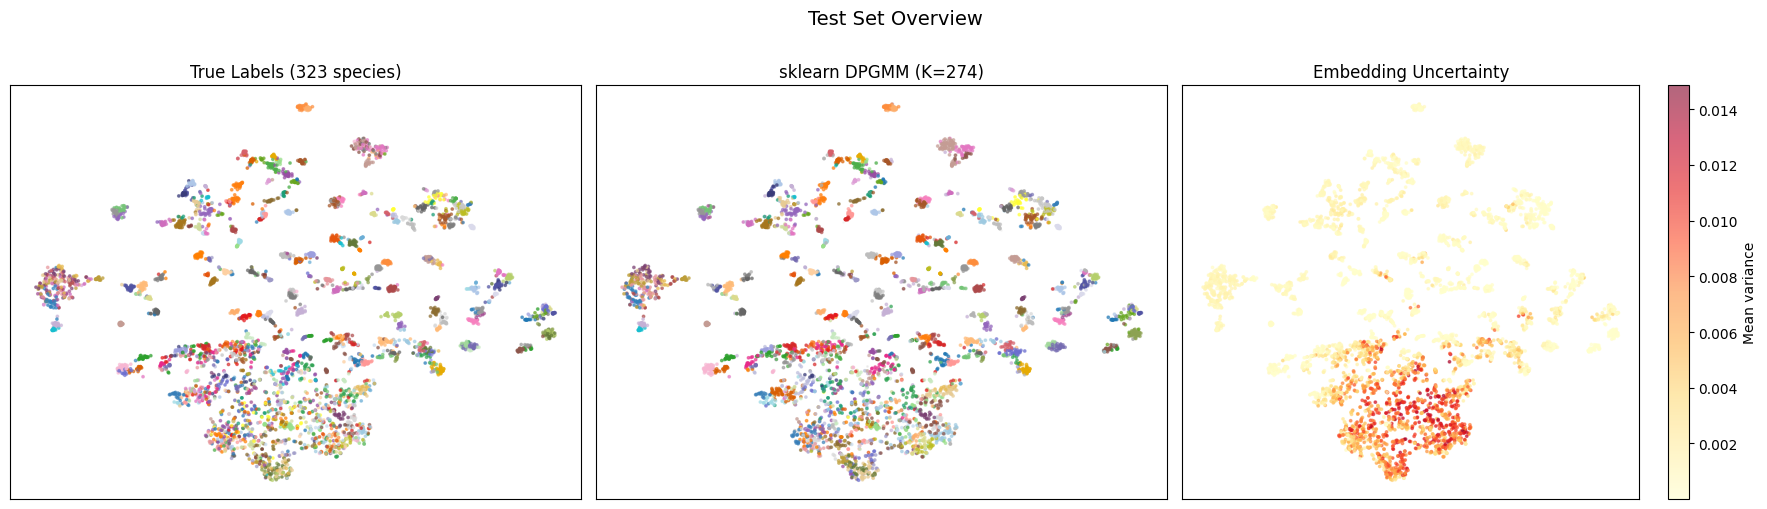

In [ ]:
# ── 3-panel scatter: True, sklearn, uncertainty ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: True labels
true_colors = np.array([species_color[l] for l in true_sub])
axes[0].scatter(Z[:, 0], Z[:, 1], c=true_colors, s=s, alpha=alpha, rasterized=True)
axes[0].set_title(f'True Labels ({n_species} species)')
axes[0].set_xticks([]); axes[0].set_yticks([])

# Panel 2: sklearn predictions (Hungarian-aligned)
sklearn_sub = pred_sklearn[sub_idx]
assigned_sk = sklearn_sub >= 0
alignment_sk = align_labels_via_hungarian_algorithm(
    true_sub[assigned_sk], sklearn_sub[assigned_sk])

sk_colors = np.full((n_sub, 4), 0.7)
for c in sorted(set(sklearn_sub[assigned_sk])):
    mask = sklearn_sub == c
    matched_sp = alignment_sk.get(c, -1)
    sk_colors[mask] = species_color.get(matched_sp, [0.7, 0.7, 0.7, 1.0])

if (~assigned_sk).any():
    axes[1].scatter(Z[~assigned_sk, 0], Z[~assigned_sk, 1],
                    c='lightgray', s=1, alpha=0.15, rasterized=True)
axes[1].scatter(Z[assigned_sk, 0], Z[assigned_sk, 1],
                c=sk_colors[assigned_sk], s=s, alpha=alpha, rasterized=True)
axes[1].set_title(f'sklearn DPGMM (K={k_sklearn})')
axes[1].set_xticks([]); axes[1].set_yticks([])

# Panel 3: Uncertainty heatmap
mean_var = var_sub.mean(axis=1)
sc = axes[2].scatter(Z[:, 0], Z[:, 1], c=mean_var, cmap='YlOrRd',
                     s=s, alpha=alpha, rasterized=True)
plt.colorbar(sc, ax=axes[2], label='Mean variance')
axes[2].set_title('Embedding Uncertainty')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.suptitle('Test Set Overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Sklearn DPGMM: Rejection Analysis

Same entropy and max-responsibility rejection sweeps, but for the sklearn
baseline on point estimates. This lets us compare whether the rejection
signal is equally useful without heteroscedastic variance.

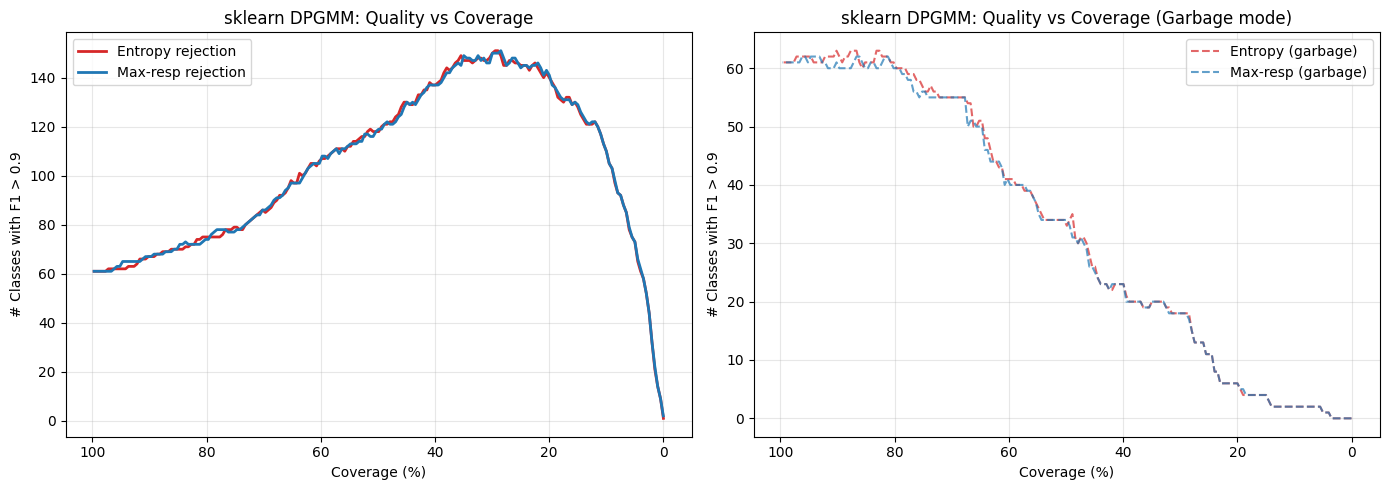

In [ ]:
# ── Sklearn DPGMM: rejection sweeps (entropy + max-resp) ──
from scipy.special import logsumexp as _logsumexp

# Get responsibilities from sklearn's fitted model
X_sk_pca = sklearn_result['pca'].transform(ug_test.point_estimate)
sk_resp_all = sklearn_result['bgm'].predict_proba(X_sk_pca)

eps = 1e-10
N_sk = len(sk_resp_all)

# Entropy (normalized)
K_sk = sk_resp_all.shape[1]
sk_resp_clipped = np.clip(sk_resp_all, eps, None)
sk_entropy_all = -np.sum(sk_resp_all * np.log(sk_resp_clipped), axis=1) / np.log(K_sk)

# Max responsibility
sk_max_resp_all = sk_resp_all.max(axis=1)

# ── Entropy sweep (coverage-based) ──
target_coverages_sk = np.arange(0, 100.5, 0.5)
sk_entropy_sweep = []
sk_pred_base = sklearn_result['pred']

for cov_target in target_coverages_sk:
    et = np.percentile(sk_entropy_all, cov_target)
    pred_et = sk_pred_base.copy()
    pred_et[sk_entropy_all > et] = -1
    coverage = (pred_et != -1).sum() / N_sk * 100
    r_d = count_high_quality_clusters(test_labels, pred_et, mode='discard')
    r_g = count_high_quality_clusters(test_labels, pred_et, mode='garbage')
    sk_entropy_sweep.append({
        'et': et, 'coverage': coverage,
        'f1_discard': r_d['counts'][8],
        'f1_garbage': r_g['counts'][8],
    })

# ── Max-resp sweep (coverage-based) ──
sk_conf_sweep = []

for cov_target in target_coverages_sk:
    ct = np.percentile(sk_max_resp_all, 100.0 - cov_target)
    pred_ct = sk_pred_base.copy()
    pred_ct[sk_max_resp_all < ct] = -1
    coverage = (pred_ct != -1).sum() / N_sk * 100
    r_d = count_high_quality_clusters(test_labels, pred_ct, mode='discard')
    r_g = count_high_quality_clusters(test_labels, pred_ct, mode='garbage')
    sk_conf_sweep.append({
        'ct': ct, 'coverage': coverage,
        'f1_discard': r_d['counts'][8],
        'f1_garbage': r_g['counts'][8],
    })

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sk_covs_ent = [s['coverage'] for s in sk_entropy_sweep]
sk_covs_conf = [s['coverage'] for s in sk_conf_sweep]

ax1.plot(sk_covs_ent, [s['f1_discard'] for s in sk_entropy_sweep],
         '-', color='tab:red', label='Entropy rejection', linewidth=2)
ax1.plot(sk_covs_conf, [s['f1_discard'] for s in sk_conf_sweep],
         '-', color='tab:blue', label='Max-resp rejection', linewidth=2)
ax1.set_xlabel('Coverage (%)')
ax1.set_ylabel('# Classes with F1 > 0.9')
ax1.set_title('sklearn DPGMM: Quality vs Coverage')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()

ax2.plot(sk_covs_ent, [s['f1_garbage'] for s in sk_entropy_sweep],
         '--', color='tab:red', label='Entropy (garbage)', linewidth=1.5, alpha=0.7)
ax2.plot(sk_covs_conf, [s['f1_garbage'] for s in sk_conf_sweep],
         '--', color='tab:blue', label='Max-resp (garbage)', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Coverage (%)')
ax2.set_ylabel('# Classes with F1 > 0.9')
ax2.set_title('sklearn DPGMM: Quality vs Coverage (Garbage mode)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

## Heteroscedastic DPGMM

Our `DPGMMClusterer` with MAP-EM, Dirichlet prior, PCA preprocessing (256D → 16D),
and post-EM component merging. Feeds per-sample Gaussian variance into the
likelihood: $\Sigma_{ik} = C_k + S_i$.

### Merge Threshold Sensitivity

Sweep `merge_threshold` to see how it affects K and quality.

In [ ]:
clust = DPGMMClusterer(
    max_components=HET_MAX_COMP,
    pca_dim=16,
    merge_threshold=1.5,
    covariance_type="diag",
    n_init=1,
    alpha_prior=1000.0,
    min_bin_size=MIN_BIN_SIZE,
    random_state=SEED,
)
pred_het = clust.fit_predict(ug_test)
r_het = count_high_quality_clusters(test_labels, pred_het, mode='discard')
het_result = {'pred': pred_het, 'clust': clust, 'r': r_het}

assigned = int((pred_het != -1).sum())
print(f'Het. DPGMM: K={clust.n_active_}, assigned={assigned}/{len(pred_het)}, '
      f'converged={clust.converged_}, iters={clust.n_iter_}, '
      f'F1>0.9={r_het["counts"][8]}, P>0.9={r_het["precision_counts"][8]}, '
      f'R>0.9={r_het["recall_counts"][8]}')

fit_predict: N=18639, D=256, probabilistic=True
Variance stats: min=0.000000, mean=0.002497, max=4.043753
PCA: 256D -> 16D (explained variance: 99.98%)
Run 1/1 (seed=1537436707)
  iter   0: MAP=-2657292.17, LL=498809.38, K_active=500
  iter   1: MAP=-2601574.85, LL=502690.85, K_active=500
  iter   2: MAP=-2599016.12, LL=505240.65, K_active=500
  iter   3: MAP=-2597979.85, LL=506272.40, K_active=500
  iter   4: MAP=-2597336.15, LL=506913.38, K_active=500
  iter  10: MAP=-2595713.25, LL=508530.88, K_active=500
  iter  20: MAP=-2594930.92, LL=509312.01, K_active=500
  iter  30: MAP=-2594621.54, LL=509620.58, K_active=500
  Converged at iter 34 (MAP=-2594554.34, K_active=500)
  Run 1 done: MAP=-2594554.34, K_active=500, iters=35, converged=True
Best run: MAP=-2594554.34, K_active=500
Merging components (threshold=1.50, K_before=500)...
After merging: K=178 (merged 322)
Final: K=178, assigned=18584/18639 (99.7%), conf_thresh=0.50
Het. DPGMM: K=178, assigned=18584/18639, converged=True, iter

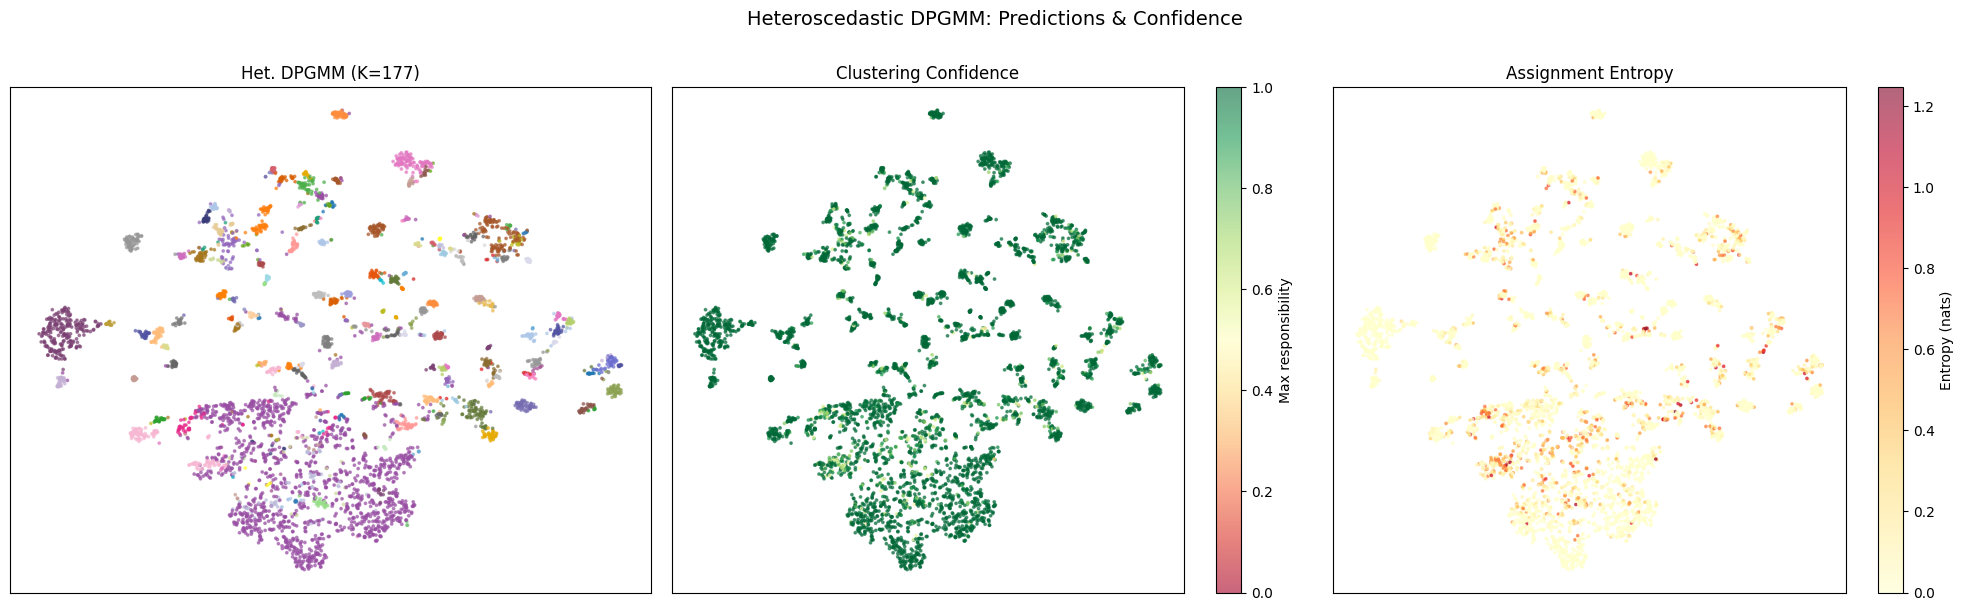

In [ ]:
# ── Het. DPGMM visualization ──
from scipy.special import logsumexp as _logsumexp

pred_sub = het_result['pred'][sub_idx]

# Compute responsibilities for subsampled points
eps = 1e-10
ug_clust = het_result['clust']
m_k, c_k, pi_k, active = ug_clust.means_, ug_clust.covariances_, ug_clust.weights_, ug_clust.active_mask_
K = len(pi_k)

# Project subsampled data to PCA space (same as clusterer used)
if ug_clust._pca is not None:
    X_sub_pca = ug_clust._pca.transform(X_sub.astype(np.float64))
    var_sub_pca = var_sub.astype(np.float64) @ (ug_clust._pca.components_.T ** 2)
else:
    X_sub_pca = X_sub.astype(np.float64)
    var_sub_pca = var_sub.astype(np.float64)

log_resp = np.full((n_sub, K), -np.inf)
for k in range(K):
    if not active[k]:
        continue
    sigma_ik = c_k[k] + var_sub_pca
    delta = X_sub_pca - m_k[k]
    log_resp[:, k] = (
        np.log(pi_k[k] + eps)
        - 0.5 * np.sum(np.log(sigma_ik + eps), axis=1)
        - 0.5 * np.sum(delta * delta / (sigma_ik + eps), axis=1)
    )
log_norm = _logsumexp(log_resp, axis=1, keepdims=True)
resp_sub = np.exp(log_resp - log_norm)
max_resp = resp_sub.max(axis=1)

# Entropy of responsibility distribution (lower = more confident)
resp_clipped = np.clip(resp_sub, eps, None)
entropy_sub = -np.sum(resp_sub * np.log(resp_clipped), axis=1)

# Hungarian alignment: predicted cluster → true species color
assigned_het = pred_sub >= 0
alignment_het = align_labels_via_hungarian_algorithm(true_sub[assigned_het], pred_sub[assigned_het])

het_colors = np.full((n_sub, 4), 0.7)
for c in sorted(set(pred_sub[assigned_het])):
    mask = pred_sub == c
    matched_sp = alignment_het.get(c, -1)
    het_colors[mask] = species_color.get(matched_sp, [0.7, 0.7, 0.7, 1.0])

# ── Plot ──
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

pred_unique = sorted(set(pred_sub[assigned_het]))
n_pred = len(pred_unique)

# Panel 1: Het. DPGMM predictions
if (~assigned_het).any():
    ax1.scatter(Z[~assigned_het, 0], Z[~assigned_het, 1],
                c='lightgray', s=1, alpha=0.15, rasterized=True)
ax1.scatter(Z[assigned_het, 0], Z[assigned_het, 1],
            c=het_colors[assigned_het], s=s, alpha=alpha, rasterized=True)
ax1.set_title(f'Het. DPGMM (K={n_pred})')
ax1.set_xticks([]); ax1.set_yticks([])

# Panel 2: Confidence heatmap (max responsibility)
sc = ax2.scatter(Z[:, 0], Z[:, 1], c=max_resp, cmap='RdYlGn',
                s=s, alpha=alpha, vmin=0, vmax=1, rasterized=True)
plt.colorbar(sc, ax=ax2, label='Max responsibility')
ax2.set_title('Clustering Confidence')
ax2.set_xticks([]); ax2.set_yticks([])

# Panel 3: Entropy heatmap (low = confident, high = uncertain)
sc3 = ax3.scatter(Z[:, 0], Z[:, 1], c=entropy_sub, cmap='YlOrRd',
                  s=s, alpha=alpha, rasterized=True)
plt.colorbar(sc3, ax=ax3, label='Entropy (nats)')
ax3.set_title('Assignment Entropy')
ax3.set_xticks([]); ax3.set_yticks([])

plt.suptitle('Heteroscedastic DPGMM: Predictions & Confidence', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Entropy-Based Rejection

The heteroscedastic DPGMM assigns responsibilities (soft probabilities) to
each sample. The entropy of the responsibility vector measures assignment
uncertainty: low entropy means confident assignment to one component, high
entropy means probability is spread across many components.

Sweeping an entropy threshold trades coverage for quality — rejecting
high-entropy (uncertain) samples — **without** retraining.

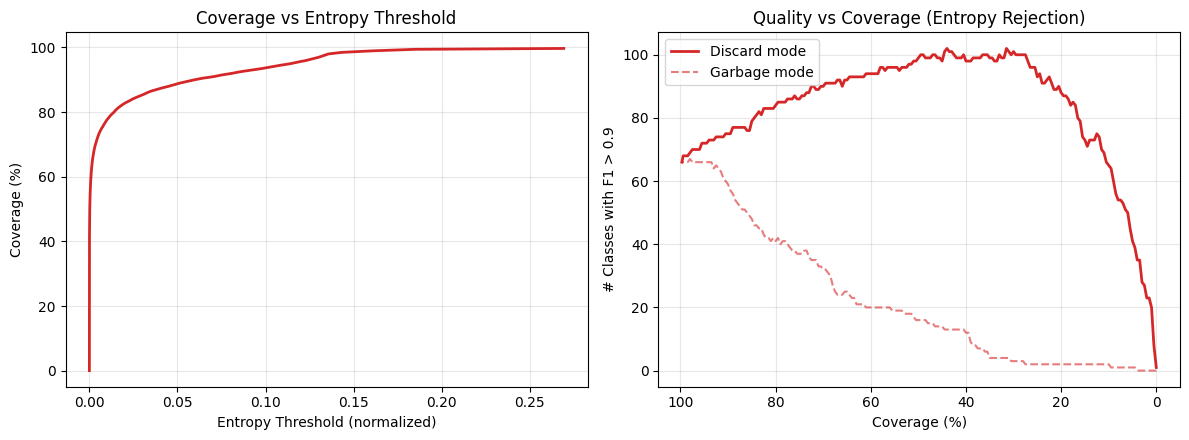

In [ ]:
# ── Entropy-based rejection sweep ──
from scipy.special import logsumexp as _logsumexp

clust_ent = het_result['clust']
m_k = clust_ent.means_
c_k = clust_ent.covariances_
pi_k = clust_ent.weights_
active = clust_ent.active_mask_
K = len(pi_k)
eps = 1e-10

# Project all test data to PCA space (matching clusterer)
if clust_ent._pca is not None:
    X_all = clust_ent._pca.transform(ug_test.mean.astype(np.float64))
    V_all = ug_test.variance.astype(np.float64) @ (clust_ent._pca.components_.T ** 2)
else:
    X_all = ug_test.mean.astype(np.float64)
    V_all = ug_test.variance.astype(np.float64)

# Compute responsibilities for all test points
log_resp = np.full((len(X_all), K), -np.inf)
for k in range(K):
    if not active[k]:
        continue
    sigma_ik = c_k[k] + V_all
    delta = X_all - m_k[k]
    log_resp[:, k] = (
        np.log(pi_k[k] + eps)
        - 0.5 * np.sum(np.log(sigma_ik + eps), axis=1)
        - 0.5 * np.sum(delta * delta / (sigma_ik + eps), axis=1)
    )
log_norm = _logsumexp(log_resp, axis=1, keepdims=True)
resp_all = np.exp(log_resp - log_norm)

# Entropy of responsibility distribution, normalized to [0, 1]
K_active = int(active.sum())
resp_clipped = np.clip(resp_all, eps, None)
entropy_all = -np.sum(resp_all * np.log(resp_clipped), axis=1) / np.log(K_active)

# Sweep by target coverage (evenly spaced) instead of entropy thresholds
# For each target coverage c%, use the c-th percentile of entropy as threshold
target_coverages = np.arange(0, 100.5, 0.5)
sorted_entropy = np.sort(entropy_all)
N = len(entropy_all)
pred_base = het_result['pred']
entropy_sweep = []

for cov_target in target_coverages:
    # Entropy threshold = value below which cov_target% of points fall
    et = np.percentile(entropy_all, cov_target)
    pred_et = pred_base.copy()
    pred_et[entropy_all > et] = -1
    coverage = (pred_et != -1).sum() / N * 100
    r_d = count_high_quality_clusters(test_labels, pred_et, mode='discard')
    r_g = count_high_quality_clusters(test_labels, pred_et, mode='garbage')
    entropy_sweep.append({
        'et': et, 'coverage': coverage,
        'f1_discard': r_d['counts'][8],
        'f1_garbage': r_g['counts'][8],
    })

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

covs = [s['coverage'] for s in entropy_sweep]
ets  = [s['et'] for s in entropy_sweep]

ax1.plot(ets, covs, '-', color='tab:red', linewidth=2)
ax1.set_xlabel('Entropy Threshold (normalized)')
ax1.set_ylabel('Coverage (%)')
ax1.set_title('Coverage vs Entropy Threshold')
ax1.grid(True, alpha=0.3)

ax2.plot(covs, [s['f1_discard'] for s in entropy_sweep],
         '-', color='tab:red', label='Discard mode', linewidth=2)
ax2.plot(covs, [s['f1_garbage'] for s in entropy_sweep],
         '--', color='tab:red', alpha=0.6, label='Garbage mode', linewidth=1.5)
ax2.set_xlabel('Coverage (%)')
ax2.set_ylabel('# Classes with F1 > 0.9')
ax2.set_title('Quality vs Coverage (Entropy Rejection)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

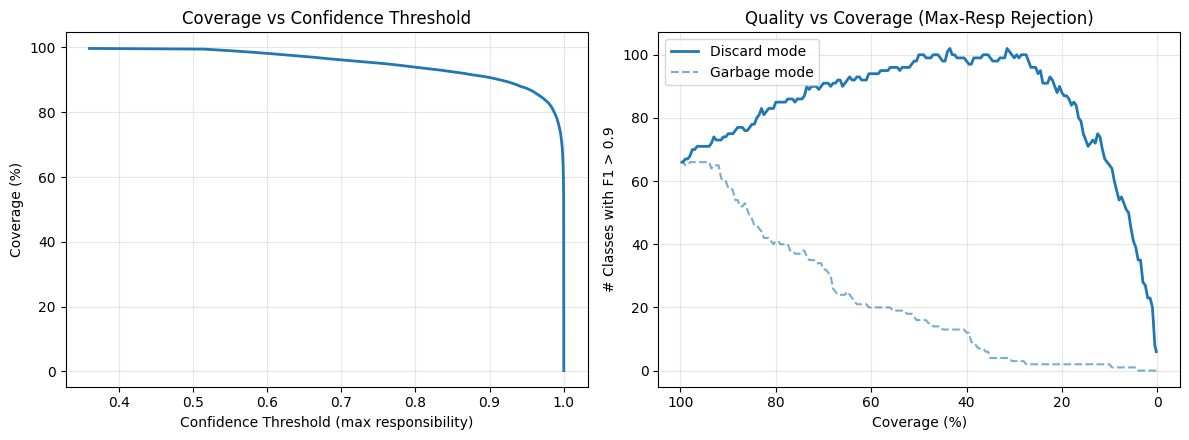

In [ ]:
# ── Max-responsibility rejection sweep ──
# Reuse resp_all and pred_base from the entropy cell above
max_resp_all = resp_all.max(axis=1)

# Sweep by target coverage (evenly spaced), same approach as entropy cell
target_coverages_conf = np.arange(0, 100.5, 0.5)
N = len(max_resp_all)
conf_sweep = []

for cov_target in target_coverages_conf:
    # Max-resp threshold = value above which cov_target% of points fall
    # i.e. the (100 - cov_target)-th percentile of max_resp
    ct = np.percentile(max_resp_all, 100.0 - cov_target)
    pred_ct = pred_base.copy()
    pred_ct[max_resp_all < ct] = -1
    coverage = (pred_ct != -1).sum() / N * 100
    r_d = count_high_quality_clusters(test_labels, pred_ct, mode='discard')
    r_g = count_high_quality_clusters(test_labels, pred_ct, mode='garbage')
    conf_sweep.append({
        'ct': ct, 'coverage': coverage,
        'f1_discard': r_d['counts'][8],
        'f1_garbage': r_g['counts'][8],
    })

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

covs = [s['coverage'] for s in conf_sweep]
cts  = [s['ct'] for s in conf_sweep]

ax1.plot(cts, covs, '-', color='tab:blue', linewidth=2)
ax1.set_xlabel('Confidence Threshold (max responsibility)')
ax1.set_ylabel('Coverage (%)')
ax1.set_title('Coverage vs Confidence Threshold')
ax1.grid(True, alpha=0.3)

ax2.plot(covs, [s['f1_discard'] for s in conf_sweep],
         '-', color='tab:blue', label='Discard mode', linewidth=2)
ax2.plot(covs, [s['f1_garbage'] for s in conf_sweep],
         '--', color='tab:blue', alpha=0.6, label='Garbage mode', linewidth=1.5)
ax2.set_xlabel('Coverage (%)')
ax2.set_ylabel('# Classes with F1 > 0.9')
ax2.set_title('Quality vs Coverage (Max-Resp Rejection)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

In [ ]:
# ── Combined: Het DPGMM Entropy vs Max-Resp rejection ──
fig, ax = plt.subplots(figsize=(8, 5))

covs_ent = [s['coverage'] for s in entropy_sweep]
covs_conf = [s['coverage'] for s in conf_sweep]

ax.plot(covs_ent, [s['f1_discard'] for s in entropy_sweep],
        '-', color='tab:red', label='Het. DPGMM — Entropy', linewidth=2)
ax.plot(covs_conf, [s['f1_discard'] for s in conf_sweep],
        '-', color='tab:blue', label='Het. DPGMM — Max-resp', linewidth=2)

ax.set_xlabel('Coverage (%)')
ax.set_ylabel('# Classes with F1 > 0.9')
ax.set_title('Het. DPGMM: Quality vs Coverage')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.show()

## Comparison: All Methods at 100% Coverage

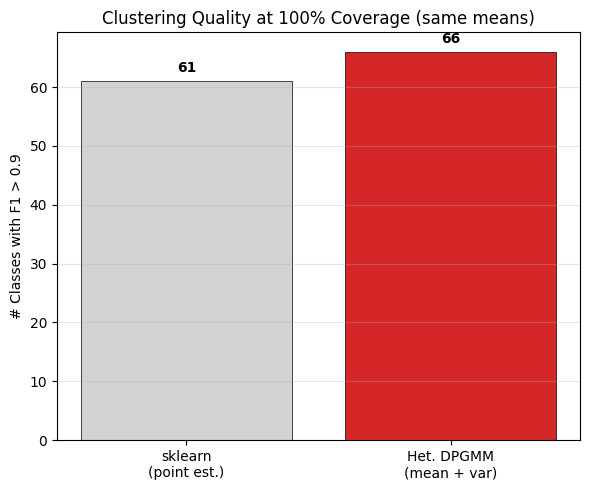

In [ ]:
# Collect results for bar chart
bar_data = {
    'sklearn\n(point est.)':     sklearn_result['r']['counts'][8],
    'Het. DPGMM\n(mean + var)':  het_result['r']['counts'][8],
}

colors = ['lightgray', 'tab:red']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(bar_data.keys(), bar_data.values(), color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, bar_data.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('# Classes with F1 > 0.9')
ax.set_title('Clustering Quality at 100% Coverage (same means)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Per-Class Quality Distribution

CDF of per-class F1 scores: how many classes achieve at least a given F1?

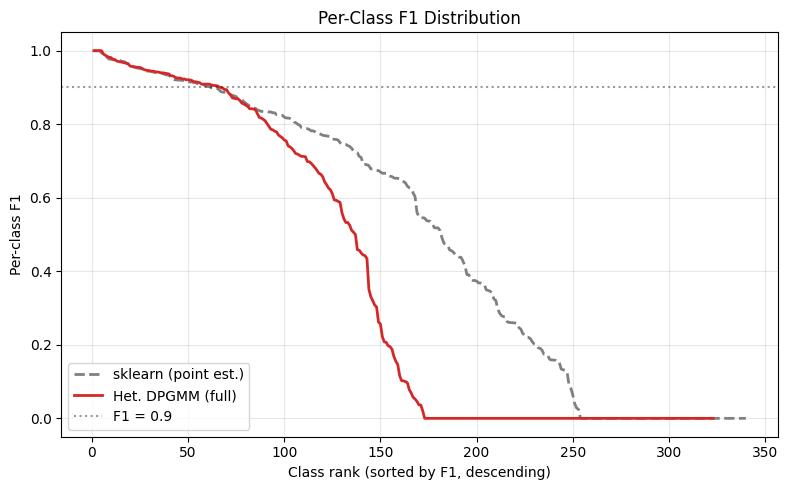

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, r, color, ls in [
    ('sklearn (point est.)', sklearn_result['r'], 'gray', '--'),
    ('Het. DPGMM (full)', het_result['r'], 'tab:red', '-'),
]:
    f1s = np.sort(r['per_class_f1'])[::-1]
    ax.plot(np.arange(1, len(f1s) + 1), f1s, ls, color=color, label=label, linewidth=2)

ax.axhline(y=0.9, color='black', linestyle=':', alpha=0.4, label='F1 = 0.9')
ax.set_xlabel('Class rank (sorted by F1, descending)')
ax.set_ylabel('Per-class F1')
ax.set_title('Per-Class F1 Distribution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cluster Diagnostics

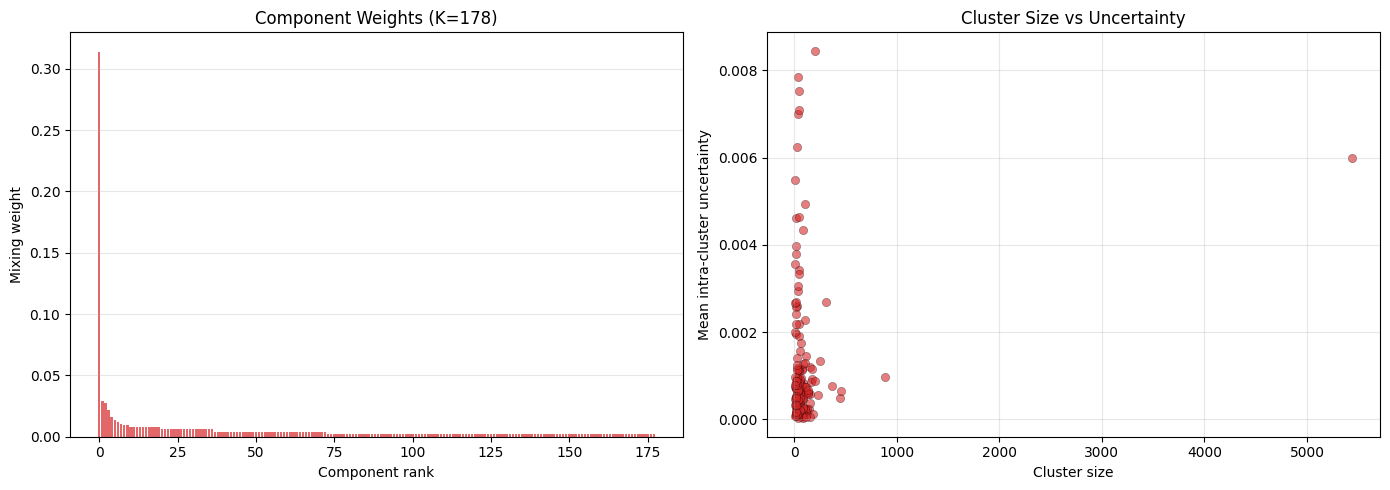

Total clusters: 178
Cluster sizes: min=7, median=49, max=5440
Mean uncertainty: min=0.00002, max=0.00845


In [ ]:
ug_full_pred = het_result['pred']
ug_full_clust = het_result['clust']

# Active weights
active_weights = ug_full_clust.weights_[ug_full_clust.active_mask_]
active_weights_sorted = np.sort(active_weights)[::-1]

# Per-cluster stats
cluster_ids = sorted(set(ug_full_pred[ug_full_pred >= 0]))
cluster_sizes = []
cluster_mean_unc = []

for c in cluster_ids:
    mask = ug_full_pred == c
    cluster_sizes.append(int(mask.sum()))
    cluster_mean_unc.append(float(ug_test.variance[mask].mean()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sorted component weights
ax1.bar(range(len(active_weights_sorted)), active_weights_sorted, color='tab:red', alpha=0.7)
ax1.set_xlabel('Component rank')
ax1.set_ylabel('Mixing weight')
ax1.set_title(f'Component Weights (K={len(active_weights_sorted)})')
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Cluster size vs mean uncertainty
sc = ax2.scatter(cluster_sizes, cluster_mean_unc, c='tab:red', alpha=0.6, edgecolors='black', linewidth=0.3)
ax2.set_xlabel('Cluster size')
ax2.set_ylabel('Mean intra-cluster uncertainty')
ax2.set_title('Cluster Size vs Uncertainty')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total clusters: {len(cluster_ids)}')
print(f'Cluster sizes: min={min(cluster_sizes)}, median={int(np.median(cluster_sizes))}, max={max(cluster_sizes)}')
print(f'Mean uncertainty: min={min(cluster_mean_unc):.5f}, max={max(cluster_mean_unc):.5f}')

In [ ]:
# ── Summary Table ──
print(f'{"Method":>25s}  {"K":>5s}  {"Assigned%":>9s}  '
      f'{"P>0.9":>6s}  {"R>0.9":>6s}  {"F1>0.9":>7s}')
print('-' * 70)

rows = [
    ('sklearn (point est.)',  sklearn_result['k'],
     sklearn_result['pred'],  sklearn_result['r']),
    ('Het. DPGMM (full)',     het_result['clust'].n_active_,
     het_result['pred'],      het_result['r']),
]

for name, k, pred, r in rows:
    assigned_pct = (pred != -1).sum() / len(pred) * 100
    print(f'{name:>25s}  {k:5d}  {assigned_pct:8.1f}%  '
          f'{r["precision_counts"][8]:6d}  {r["recall_counts"][8]:6d}  '
          f'{r["counts"][8]:7d}')

                   Method      K  Assigned%   P>0.9   R>0.9   F1>0.9
----------------------------------------------------------------------
     sklearn (point est.)    274      99.7%      94      65       61
        Het. DPGMM (full)    178      99.7%      81      78       66


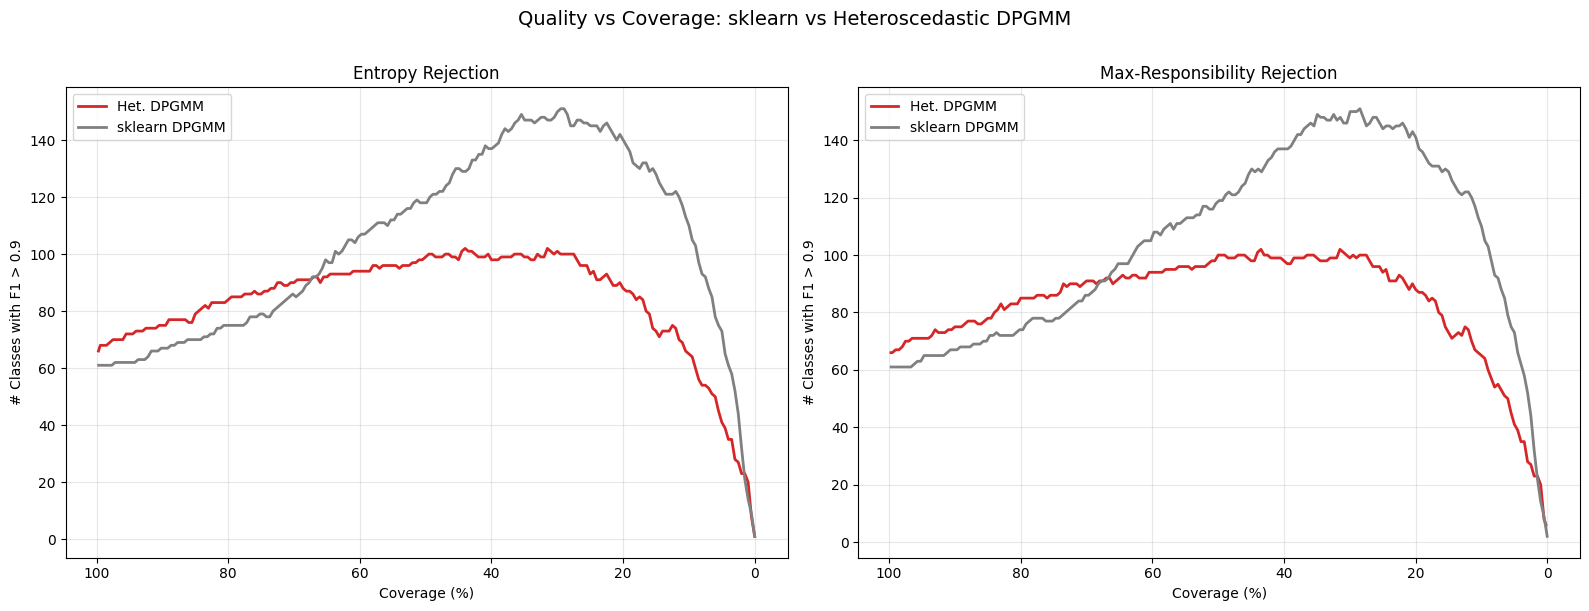

In [ ]:
# ── Final comparison: sklearn vs Het. DPGMM quality-vs-coverage ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Entropy rejection
het_covs_ent = [s['coverage'] for s in entropy_sweep]
sk_covs_ent  = [s['coverage'] for s in sk_entropy_sweep]

ax1.plot(het_covs_ent, [s['f1_discard'] for s in entropy_sweep],
         '-', color='tab:red', label='Het. DPGMM', linewidth=2)
ax1.plot(sk_covs_ent, [s['f1_discard'] for s in sk_entropy_sweep],
         '-', color='gray', label='sklearn DPGMM', linewidth=2)
ax1.set_xlabel('Coverage (%)')
ax1.set_ylabel('# Classes with F1 > 0.9')
ax1.set_title('Entropy Rejection')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()

# Panel 2: Max-resp rejection
het_covs_conf = [s['coverage'] for s in conf_sweep]
sk_covs_conf  = [s['coverage'] for s in sk_conf_sweep]

ax2.plot(het_covs_conf, [s['f1_discard'] for s in conf_sweep],
         '-', color='tab:red', label='Het. DPGMM', linewidth=2)
ax2.plot(sk_covs_conf, [s['f1_discard'] for s in sk_conf_sweep],
         '-', color='gray', label='sklearn DPGMM', linewidth=2)
ax2.set_xlabel('Coverage (%)')
ax2.set_ylabel('# Classes with F1 > 0.9')
ax2.set_title('Max-Responsibility Rejection')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

plt.suptitle('Quality vs Coverage: sklearn vs Heteroscedastic DPGMM', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()